In [8]:
import sys
import os
import numpy as np
import pandas as pd

In [9]:
eye_data_path = '/data/pt_02747/action_hippo/data/derivatives/eyetracker/'
event_data_path = '/data/pt_02747/action_hippo/data/'
# subs are all subjects in event_data_path
subs = os.listdir(event_data_path)
subs = [sub for sub in subs if 'sub' in sub]
subs = [sub for sub in subs if '.' not in sub]
subs = sorted(subs)

bad_subs = ['03', '04', '05', '06', '08', '09', '32', '35', '40', '41', '45', '50', '57']
bad_subs = ['sub-' + sub for sub in bad_subs]
subs = [sub for sub in subs if sub not in bad_subs]
len(subs)


44

In [3]:
sub = subs[0]
# create empty df with columns "sub", "condition", "mean_x", "mean_y", "window", "method"


In [4]:

# get event files, which are divided by runs, and append into one big df

for run in ['01', '02', '03', '04']:
    # get event files
    event_file = os.path.join(eye_data_path, sub, sub + '_task-probe_run-' + run + '_events.tsv')
    # read in event file
    df = pd.read_csv(event_file, sep='\t')
    # add run column
    df['run'] = run[-1]
    # append to big df
    if run == '01':
        df_all = df
    else:
        df_all = pd.concat([df_all, df], axis=0)

df_all.head()

,onset,duration,trial_type,stimulus,run
0,358.799436,2.0,3,33.0,1
1,358.799436,2.0,stimulus,33.0,1
2,362.381885,2.0,stimulus,34.0,1
3,362.381885,2.0,4,34.0,1
4,365.414362,2.0,stimulus,61.0,1


In [5]:
# get eye data files, which are in one big file
# get files in sub folder
files = os.listdir(os.path.join(eye_data_path, sub))
# get only eye data files
files = [file for file in files if 'eye' in file and 'cleaned' in file and 'csv' in file]
file = files[0]

print(files)

# read in eye data file
df_eye = pd.read_csv(os.path.join(eye_data_path, sub, file), sep=',')
df_eye.head()


['sub-01_eye_data_20230601_1624_cleaned.csv']


,time_rounded,time,left_gaze_x,left_gaze_y,left_pupil_measure1,right_gaze_x,right_gaze_y,right_pupil_measure1,status,status_buffer_100,mean_gaze_x,mean_gaze_y
0,318.580,318.580091,-0.030093,0.051389,1666.0,-0.017037,0.061111,1518.0,0.0,0.0,-0.023565,0.056250
1,318.581,318.581244,-0.028704,0.048889,1670.0,-0.016667,0.057407,1528.0,0.0,0.0,-0.022685,0.053148
2,318.582,318.582258,-0.030000,0.049259,1670.0,-0.016852,0.058796,1529.0,0.0,0.0,-0.023426,0.054028
3,318.583,318.583425,-0.029537,0.051204,1670.0,-0.016574,0.060000,1530.0,0.0,0.0,-0.023056,0.055602
4,318.585,318.584564,-0.029259,0.050556,1667.0,-0.017315,0.059352,1529.0,0.0,0.0,-0.023287,0.054954


In [7]:
# optimise processing time by excluding any timestamps before the first onset
# get first onset
first_onset = df_all['onset'].min()
# exclude rows in eye data before first onset
df_eye = df_eye[df_eye['time'] >= first_onset-1]

In [9]:
# get subject baseline for gaze to exclude anything weird
# baseline is median of whole eye data file for mean x and y
baseline_x = df_eye['mean_gaze_x'].median()
baseline_y = df_eye['mean_gaze_y'].median()
baseline_x

-0.0008796127513051

In [10]:
# get onsets of events for each condition in df_all

conditions = ['1', '2', '3', '4']

onsets_cond = {}

for cond in conditions:
    onsets_cond_unrounded = df_all[df_all['trial_type'] == cond]['onset'].values
    # round to 3dp
    onsets_cond_rounded = np.round(onsets_cond_unrounded, 3)
    onsets_cond[cond] = onsets_cond_rounded


In [11]:
# for each condition, take onsets, get median x and y coordinates for interval in 1000 to 2000ms after onset

window = [0.85, 0.87]

# create list of timecourse intervals, which are values in range 0,2 with step 0.001
timecourse_vals = np.arange(window[0], window[1], 0.001)

summary_df = pd.DataFrame(columns=["sub", "condition", "mean_x", "mean_y", "window", "method"])
timecourse_df = pd.DataFrame(columns=["sub", "condition", "mean_x", "mean_y", "time", "method"])

for cond in conditions:
    onsets = onsets_cond[cond]
    
    # create empty 2d array for median x and y coordinates, with length of onsets
    median_x = np.empty(len(onsets))
    median_y = np.empty(len(onsets))

    # for each onset, get median x and y coordinates for interval in 1000 to 2000ms after onset
    for onset_i in range(len(onsets)):
        time_window_start = onsets[onset_i] + window[0] # start is inclusive
        time_window_end = onsets[onset_i] + window[1] # end is not inclusive

        df_window = df_eye[(df_eye['time'] >= time_window_start) & (df_eye['time'] <= time_window_end)] # get rows in time window

        # exclude rows with missing data, e.g. nans in mean gaze
        df_window = df_window[df_window['mean_gaze_x'].notna()]
        df_window = df_window[df_window['mean_gaze_y'].notna()]

        median_x[onset_i] = df_window['mean_gaze_x'].median() # mean gaze means the mean of the left and right eye
        median_y[onset_i] = df_window['mean_gaze_y'].median() # mean gaze means the mean of the left and right eye


    # get median x and y for each timecourse value post onset
    for timecourse_val in timecourse_vals:
        list_vals_x = []
        list_vals_y = []
        for onset in onsets:
            timepoint = onset + timecourse_val
            # see if we have any x or y values for this timepoint
            df_timepoint = df_eye[(df_eye['time_rounded'] == timepoint)]

            #print('timepoint: ', timepoint)
            # print df_timepoint
            #print('timepoint: ', df_timepoint)

            if len(df_timepoint) == 0:
                list_vals_x.append(np.nan)
                list_vals_y.append(np.nan)
            else:
                list_vals_x.append(df_timepoint['mean_gaze_x'].median() - baseline_x)
                list_vals_y.append(df_timepoint['mean_gaze_y'].median() - baseline_y)
        

        # remove nans
        list_vals_x = [x for x in list_vals_x if str(x) != 'nan']
        list_vals_y = [y for y in list_vals_y if str(y) != 'nan']

        # ideal is number of trials per condition * 4, which should be 64
        print('x values: ', len(list_vals_x))

        # take median of all values for this timepoint
        timepoint_median_x = np.median(list_vals_x)
        timepoint_median_y = np.median(list_vals_y)

        # concat to timecourse df
        row_df = pd.DataFrame([[sub, cond, timepoint_median_x, timepoint_median_y, timecourse_val, 'median']], columns=["sub", "condition", "mean_x", "mean_y", "time", "method"])
        timecourse_df = pd.concat([timecourse_df, row_df], ignore_index=True)
        

    # take mean of median x and y coordinates to give one value for each condition
    median_x = median_x[~np.isnan(median_x)]
    median_y = median_y[~np.isnan(median_y)]

    mean_x = median_x.mean() - baseline_x
    mean_y = median_y.mean() - baseline_y
    # concat to summary df
    row_df = pd.DataFrame([[sub, cond, mean_x, mean_y, str(window[0])+'_'+str(window[1]), 'median']], columns=["sub", "condition", "mean_x", "mean_y", "window", "method"])
    # concat to summary df
    summary_df = pd.concat([summary_df, row_df], ignore_index=True)


x values:  34
x values:  42


/tmp/ipykernel_23217/3885994669.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  timecourse_df = pd.concat([timecourse_df, row_df], ignore_index=True)


x values:  36
x values:  48
x values:  44
x values:  46
x values:  57
x values:  46
x values:  41
x values:  32
x values:  37
x values:  37
x values:  40
x values:  42
x values:  43
x values:  56
x values:  52
x values:  43
x values:  34
x values:  29
x values:  37


/tmp/ipykernel_23217/3885994669.py:79: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary_df = pd.concat([summary_df, row_df], ignore_index=True)


x values:  30
x values:  45
x values:  39
x values:  40
x values:  46
x values:  50
x values:  53
x values:  38
x values:  35
x values:  29
x values:  35
x values:  45
x values:  37
x values:  44
x values:  47
x values:  53
x values:  50
x values:  38
x values:  35
x values:  30
x values:  32
x values:  43
x values:  39
x values:  27
x values:  29
x values:  44
x values:  45
x values:  47
x values:  42
x values:  36
x values:  41
x values:  38
x values:  34
x values:  31
x values:  40
x values:  46
x values:  52
x values:  46
x values:  40
x values:  43
x values:  39
x values:  39
x values:  30
x values:  38
x values:  37
x values:  44
x values:  35
x values:  42
x values:  48
x values:  40
x values:  44
x values:  29
x values:  33
x values:  36
x values:  41
x values:  36
x values:  41
x values:  49
x values:  47
x values:  45
x values:  31
x values:  33
x values:  34


/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


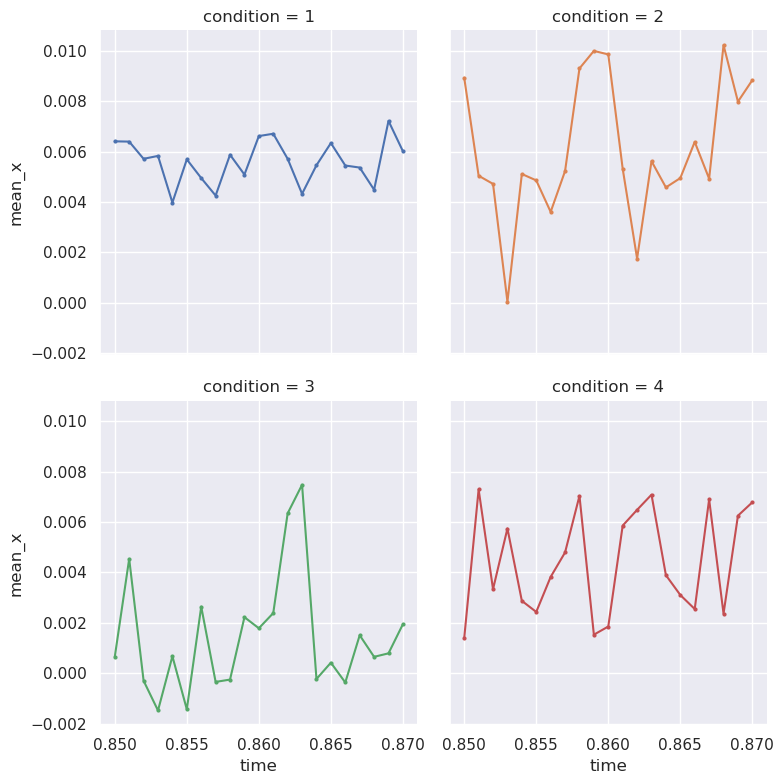

In [14]:
# plot timecourse of gaze for each condition
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="darkgrid")

g = sns.FacetGrid(timecourse_df, col="condition", hue="condition", col_wrap=2, height=4)
g.map(plt.plot, "time", "mean_x", marker="o", ms=2)

Try with all subs

In [11]:
import copy

# create empty df with columns "sub", "condition", "mean_x", "mean_y", "window", "method"
summary_df = pd.DataFrame(columns=["sub", "condition", "mean_x", "mean_y", "window", "method"])
# create empty df with columns "sub", "condition", "mean_x", "mean_y", "time", "method"
#timecourse_df = pd.DataFrame(columns=["sub", "condition", "mean_x", "mean_y", "time", "method", 'num_xvals', 'num_yvals'])

timecourse_df = pd.DataFrame(columns=["sub", "condition", "mean_gaze_x", "mean_gaze_y", "time_rounded_relative", "method"])

# create empty df with columns "sub", "condition", "onset", "run", "data"
trials_used_df = pd.DataFrame(columns=["sub", "condition", "onset", "run", "data", 'data_num'])

# list conditions
conditions = ['1', '2', '3', '4']
# time window in which to carry out analyses
window = [-0.501, 2.5]

# create list of timecourse intervals, which are values in range 0,2 with step 0.001
timecourse_vals = np.arange(window[0], window[1], 0.001)

for sub in subs:
    print('processing sub', sub)
    try:
        # =============================================================================
        # get event files, which are divided by runs, and append into one big df
        for run in ['01', '02', '03', '04']:
            # get event files
            event_file = os.path.join(eye_data_path, sub, sub + '_task-probe_run-' + run + '_events.tsv')
            # read in event file
            df = pd.read_csv(event_file, sep='\t')
            # add run column
            df['run'] = run[-1]
            # append to big df
            if run == '01':
                df_all = df
            else:
                df_2 = df
                # concatenate
                df_all = pd.concat([df_all, df_2], ignore_index=True)

        # get eye data files, which are in one big file
        # get files in sub folder
        files = os.listdir(os.path.join(eye_data_path, sub))
        # get only eye data files
        files = [file for file in files if 'eye' in file and 'cleaned' in file and 'csv' in file]
        file = files[0]

        # =============================================================================

        # read in eye data file
        df_eye = pd.read_csv(os.path.join(eye_data_path, sub, file), sep=',')

        # we only need 'time_rounded', 'mean_gaze_x', 'mean_gaze_y'
        df_eye = df_eye[['time','time_rounded', 'mean_gaze_x', 'mean_gaze_y']]


        # =============================================================================

        # exlude points where mean_gaze_y is less than -0.5 or greater than 0.5
        df_eye = df_eye[df_eye['mean_gaze_y'] >= -0.5]
        df_eye = df_eye[df_eye['mean_gaze_y'] <= 0.5]

        # exclude points where mean_gaze_x is less than -0.89 or greater than 0.89
        df_eye = df_eye[df_eye['mean_gaze_x'] >= -0.89]
        df_eye = df_eye[df_eye['mean_gaze_x'] <= 0.89]

        # =============================================================================

        # optimise processing time by excluding any timestamps before the first onset
        # get first onset
        first_onset = df_all['onset'].min()
        # exclude rows in eye data before first onset
        df_eye = df_eye[df_eye['time'] >= first_onset-1]

        # =============================================================================

        # get subject baseline for gaze to exclude anything weird
        # baseline is median of whole eye data file for mean x and y
        baseline_x = df_eye['mean_gaze_x'].median()
        #print('baseline_x', baseline_x)
        baseline_y = df_eye['mean_gaze_y'].median()

        # =============================================================================

        # get onsets of events for each condition in df_all

        onsets_cond = {}

        for cond in conditions:
            onsets_cond_unrounded = df_all[df_all['trial_type'] == cond]['onset'].values
            # round to 3dp
            onsets_cond_rounded = np.round(onsets_cond_unrounded, 3)
            onsets_cond[cond] = onsets_cond_rounded

        # =============================================================================

        # for each condition, take onsets, get median x and y coordinates for interval in 1000 to 2000ms after onset

        for cond in conditions:
            onsets = onsets_cond[cond]



            # comment below out if we don't need a summary
            '''
            # create empty 2d array for median x and y coordinates, with length of onsets
            median_x = np.empty(len(onsets))
            median_y = np.empty(len(onsets))

            # for each onset, get median x and y coordinates for interval in -500ms to 2500ms after onset (defined by window)
            for onset_i in range(len(onsets)):
                time_window_start = onsets[onset_i] + window[0] # start is inclusive
                time_window_end = onsets[onset_i] + window[1] # end is not inclusive

                df_window = df_eye[(df_eye['time'] >= time_window_start) & (df_eye['time'] <= time_window_end)] # get rows in time window

                # exclude rows with missing data, e.g. nans in mean gaze
                df_window = df_window[df_window['mean_gaze_x'].notna()]
                df_window = df_window[df_window['mean_gaze_y'].notna()]

                # add to trials_used_df, code data as 'yes' if len(df_window) > 500
                if len(df_window) > 500:
                    data = 'yes'
                else:
                    data = 'no'

                data_num = len(df_window)

                row_df = pd.DataFrame([[sub, cond, onsets[onset_i], run, data, data_num]], columns=["sub", "condition", "onset", "run", "data", "data_num"])
                trials_used_df = pd.concat([trials_used_df, row_df], ignore_index=True)

                median_x[onset_i] = df_window['mean_gaze_x'].median() # mean gaze means the mean of the left and right eye
                median_y[onset_i] = df_window['mean_gaze_y'].median() # mean gaze means the mean of the left and right eye
            
            # take mean of median x and y coordinates to give one value for each condition
            # note that we take mean here as we have already taken the median for each timepoint so removed a lot of noise
            # we don't have so many conditions so prefer to choose mean over median
            # might mean biasing by more extreme values of course!
            
            median_x = median_x[~np.isnan(median_x)]
            median_y = median_y[~np.isnan(median_y)]

            #print('median x', median_x) 
            mean_x = median_x.mean() - baseline_x
            #print('mean_x', mean_x)
            mean_y = median_y.mean() - baseline_y
            # concat to summary df
            row_df = pd.DataFrame([[sub, cond, mean_x, mean_y, str(window[0])+'_'+str(window[1]), 'median']], columns=["sub", "condition", "mean_x", "mean_y", "window", "method"])
            # concat to summary df
            summary_df = pd.concat([summary_df, row_df], ignore_index=True)
            '''
            
            # COMMENT OUT TO MAKE EVERYTHING FASTER
            # get median x and y for each timecourse value post onset

            # filter df_eye to get timepoints which are in onsets + timecourse_vals
            # this is to make the loop faster
            timepoints = [[(onset + timecourse_val, timecourse_val) for onset in onsets] for timecourse_val in timecourse_vals]
            timepoints = [item for sublist in timepoints for item in sublist]
            timepoints_only = [onset + timecourse_val for onset in onsets for timecourse_val in timecourse_vals]
            # create a new df with only these timepoints
            df_eye_cond = copy.deepcopy(df_eye[df_eye['time_rounded'].isin(timepoints_only)])

            # we now need to rename time_rounded relative to the onset
            # basically, every sublist in timepoints is a timecourse_val

            # create a new column for time_rounded relative to the onset
            df_eye_cond['timecourse_val'] = np.nan

            # use timepoints to get the timecourse_val, we basically have a list of tuples with (time_rounded, timecourse_val)
            # ideally use a dict for this
            timepoints_dict = {timepoint[0]: timepoint[1] for timepoint in timepoints}

            # now we can use this dict to get the timecourse_val for each time_rounded
            df_eye_cond['time_rounded_relative'] = df_eye_cond['time_rounded'].map(timepoints_dict)

            # quantify nans in df_eye_cond by looking at number of nans in mean_gaze_x
            n_nans = len(df_eye_cond[df_eye_cond['mean_gaze_x'].isna()])

            # get rid fo nans
            df_eye_cond = df_eye_cond[df_eye_cond['mean_gaze_x'].notna()]

            # get mean x and y coordinates by taking mean of all values for each timepoint
            df_eye_cond = df_eye_cond.groupby('time_rounded_relative').mean().reset_index()

            # OLD CODE BELOW - much much slower, probably
            '''
            for timecourse_val in timecourse_vals:

                list_vals_x = []
                list_vals_y = []
                for onset in onsets:
                    timepoint = onset + timecourse_val
                    # see if we have any x or y values for this timepoint
                    df_timepoint = df_eye[(df_eye['time_rounded'] == timepoint)]

                    #print('timepoint: ', timepoint)
                    # print df_timepoint
                    #print('timepoint: ', df_timepoint)

                    if len(df_timepoint) == 0:
                        list_vals_x.append(np.nan)
                        list_vals_y.append(np.nan)
                    else:
                        list_vals_x.append(df_timepoint['mean_gaze_x'].mean()) # can subtract baseline_x but we don't have to; take mean to account for rounding
                        list_vals_y.append(df_timepoint['mean_gaze_y'].mean()) # can subtract baseline_y but we don't have to; take mean to account for rounding
                
                # remove nans
                list_vals_x = [x for x in list_vals_x if x != np.nan]
                list_vals_y = [y for y in list_vals_y if y != np.nan]

                # take MEAN of all values for this timepoint
                # note that we might end up with unusual numbers of trials for each condition as we might not have data for all trials at each timepoint 
                timepoint_mean_x = np.mean(list_vals_x)
                timepoint_mean_y = np.mean(list_vals_y)

                n_x = len(list_vals_x)
                n_y = len(list_vals_y)
                

                # concat to timecourse df
                row_df = pd.DataFrame([[sub, cond, timepoint_mean_x, timepoint_mean_y, timecourse_val, 'mean', n_x, n_y]], columns=["sub", "condition", "mean_x", "mean_y", "time", "method", 'num_xvals', 'num_yvals'])
                timecourse_df = pd.concat([timecourse_df, row_df], ignore_index=True)
                '''
            
            # now we can get the mean from df_eye_cond for each timecourse_val
            # add in columns for sub, cond, method, n_nans
            df_eye_cond['sub'] = sub
            df_eye_cond['condition'] = cond
            df_eye_cond['method'] = 'mean'
            df_eye_cond['n_nans'] = n_nans
            
            # append to timecourse_df
            timecourse_df = pd.concat([timecourse_df, df_eye_cond], ignore_index=True)

    except:
        print('error with sub', sub)
        continue


# print unique subs
#print(summary_df['sub'].unique())
#print(summary_df.head())

# save summary_df
# summary_df.to_csv('/data/pt_02747/action_hippo/data/derivatives/eyetracker/20240827_summary_df.csv', index=False)

# save timecourse_df
timecourse_df.to_csv('/data/pt_02747/action_hippo/data/derivatives/eyetracker/20240827_timecourse_df.csv', index=False)




processing sub sub-01


/tmp/ipykernel_14615/3542469756.py:234: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  timecourse_df = pd.concat([timecourse_df, df_eye_cond], ignore_index=True)


processing sub sub-07
processing sub sub-10
processing sub sub-11
processing sub sub-12
processing sub sub-13
processing sub sub-14
processing sub sub-15
processing sub sub-16
processing sub sub-17
processing sub sub-19
processing sub sub-21
processing sub sub-22
processing sub sub-23
processing sub sub-24
processing sub sub-25
processing sub sub-26
processing sub sub-27
processing sub sub-28
processing sub sub-29
processing sub sub-30
processing sub sub-31
processing sub sub-34
processing sub sub-36
processing sub sub-37
processing sub sub-38
processing sub sub-39
processing sub sub-42
processing sub sub-43
processing sub sub-46
processing sub sub-47
processing sub sub-48
processing sub sub-49
processing sub sub-51
processing sub sub-52
processing sub sub-53
processing sub sub-54
error with sub sub-54
processing sub sub-55
processing sub sub-56
processing sub sub-58
processing sub sub-59
processing sub sub-60
processing sub sub-61
processing sub sub-62


/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

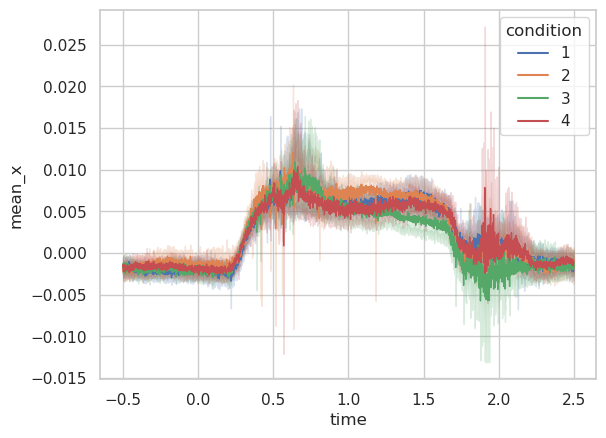

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

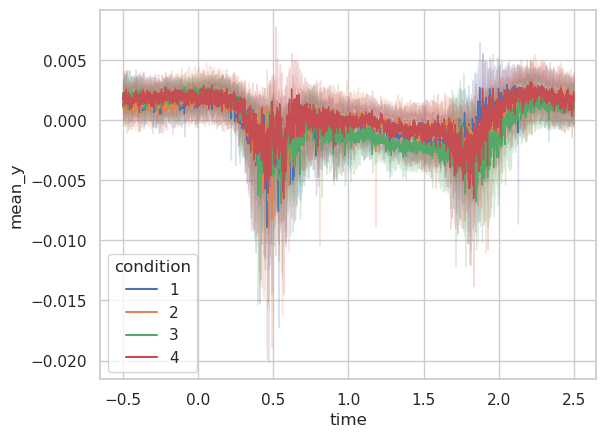

In [ ]:
# plot timecourse of gaze for each condition

# thick lines
'''
g = sns.lineplot(x="time", y="mean_x",
            data=timecourse_df,
            hue='condition',
            errorbar=('ci', 95),
            linewidth=1,
            err_style='band'

            ) 

# plot
plt.show()

# save in /data/pt_02747/action_hippo/data/derivatives/eyetracker/
g.figure.savefig(os.path.join(eye_data_path, 'timecourse_gaze_x.png'))



g = sns.lineplot(x="time", y="mean_y",
            data=timecourse_df,
            hue='condition',
            errorbar=('ci', 95),
            linewidth=1
            #errorbar=None
            )

plt.show()

# save in /data/pt_02747/action_hippo/data/derivatives/eyetracker/
g.figure.savefig(os.path.join(eye_data_path, 'timecourse_gaze_y.png'))


# save timecourse df
timecourse_df.to_csv(os.path.join(eye_data_path, 'timecourse_gaze.csv'), index=False)

# save summary df
summary_df.to_csv(os.path.join(eye_data_path, 'summary_gaze.csv'), index=False)
'''

In [ ]:
import copy
smoothed_timecourse_df = copy.deepcopy(timecourse_df)

# smooth data with gaussian filter

from scipy.ndimage import gaussian_filter1d

# for each subject
for sub in subs:
    # for each condition
    for cond in conditions:
        data_to_smooth_x = timecourse_df[(timecourse_df['sub'] == sub) & (timecourse_df['condition'] == cond)]['mean_x'].values
        data_to_smooth_y = timecourse_df[(timecourse_df['sub'] == sub) & (timecourse_df['condition'] == cond)]['mean_y'].values

        smoothed_data_x = gaussian_filter1d(data_to_smooth_x, sigma=100)
        smoothed_data_y = gaussian_filter1d(data_to_smooth_y, sigma=100)

        smoothed_timecourse_df.loc[(smoothed_timecourse_df['sub'] == sub) & (smoothed_timecourse_df['condition'] == cond), 'mean_x'] = smoothed_data_x
        smoothed_timecourse_df.loc[(smoothed_timecourse_df['sub'] == sub) & (smoothed_timecourse_df['condition'] == cond), 'mean_y'] = smoothed_data_y

In [ ]:
len(data_to_smooth_x)

3000

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

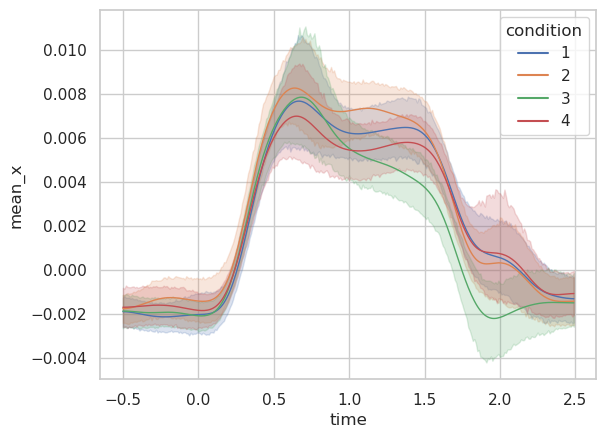

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

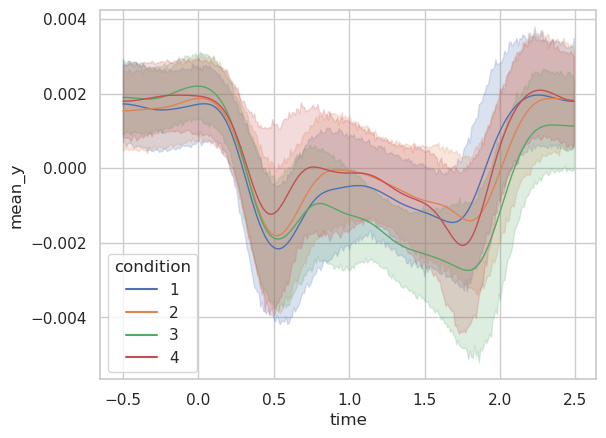

In [ ]:

# downsample smoothed timecourse df by only taking every 20th row
smoothed_timecourse_df_plot = smoothed_timecourse_df.iloc[::20, :]


g = sns.lineplot(x="time", y="mean_x",
            data=smoothed_timecourse_df_plot,
            hue='condition',
            errorbar=('ci', 95),
            linewidth=1,
            err_style='band'

            ) 

# plot
plt.show()



g = sns.lineplot(x="time", y="mean_y",
            data=smoothed_timecourse_df_plot,
            hue='condition',
            errorbar=('ci', 95),
            linewidth=1
            #errorbar=None
            )

plt.show()